# LSTM Autoencoder – Anomalieerkennung

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for _c in [Path.cwd(), Path.cwd() / "04_notebooks"]:
    if (_c / "shared_setup.py").exists():
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

from shared_setup import load_and_prepare, evaluate, alarm_analysis

train_df, test_df, rul_df, useful_sensors, scaler = load_and_prepare()

# Autoencoder-spezifisch: Training nur auf gesunden Zyklen (erste 30%)
healthy_df = train_df[train_df["cycles"] <= train_df["max_cycle"] * 0.3]

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, seq_len):
        super().__init__()
        self.seq_len = seq_len
        self.encoder = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.decoder = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.output_layer = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        hidden = hidden.permute(1, 0, 2).repeat(1, self.seq_len, 1)
        output, _ = self.decoder(hidden)
        return self.output_layer(output)

def create_sequences(df, window_size, features):
    x, labels = [], []
    for uid in df["unit_id"].unique():
        unit = df[df["unit_id"] == uid].sort_values("cycles")
        vals = unit[features].values
        for i in range(len(vals) - window_size + 1):
            x.append(vals[i:i + window_size])
            labels.append((uid, unit["cycles"].values[i + window_size - 1]))
    return np.array(x), np.array(labels)

print(LSTMAutoencoder(input_size=len(useful_sensors), hidden_size=32, seq_len=20))

LSTMAutoencoder(
  (encoder): LSTM(14, 32, batch_first=True)
  (decoder): LSTM(32, 32, batch_first=True)
  (output_layer): Linear(in_features=32, out_features=14, bias=True)
)


In [3]:
# Parameter
window_size, hidden_size, lr, epochs, threshold = 20, 32, 0.001, 50, 0.3

# Training auf gesunden Zyklen
X_tensor = torch.FloatTensor(create_sequences(healthy_df, window_size, useful_sensors)[0])
loader   = DataLoader(TensorDataset(X_tensor, X_tensor), batch_size=32, shuffle=True)
model     = LSTMAutoencoder(len(useful_sensors), hidden_size, window_size)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
torch.manual_seed(42)

for epoch in range(epochs):
    for x_batch, y_batch in loader:
        loss = criterion(model(x_batch), y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

all_sequences, labels = create_sequences(train_df, window_size, useful_sensors)
all_tensor = torch.FloatTensor(all_sequences)

# Rekonstruktionsfehler berechneen
with torch.no_grad():
    errors = torch.mean((all_tensor - model(all_tensor)) ** 2, dim=(1, 2))

In [4]:
# Ergebnisse aufbereiten
train_result = pd.DataFrame(labels, columns=["unit_id", "cycle"])
train_result["reconstruction_error"] = errors.numpy()
train_result = train_result.merge(
    train_df[["unit_id", "cycles", "RUL"]],
    left_on=["unit_id", "cycle"], right_on=["unit_id", "cycles"],
)
train_result["anomaly_flag"] = train_result["reconstruction_error"] > threshold

y_true = (train_result["RUL"] <= 30).astype(int)
y_pred = train_result["anomaly_flag"].astype(int)

In [5]:
first_alarm = (
    train_result[train_result["anomaly_flag"] == 1]
    .groupby("unit_id")["RUL"]
    .max()
)

evaluate(y_true, y_pred, "Trainingsdaten")
print(first_alarm.describe().round(1))

Trainingsdaten:
Precision: 0.7797
Recall:    0.8197
F1:        0.7992
count    100.0
mean      32.3
std       15.7
min        7.0
25%       17.8
50%       31.0
75%       43.0
max       75.0
Name: RUL, dtype: float64


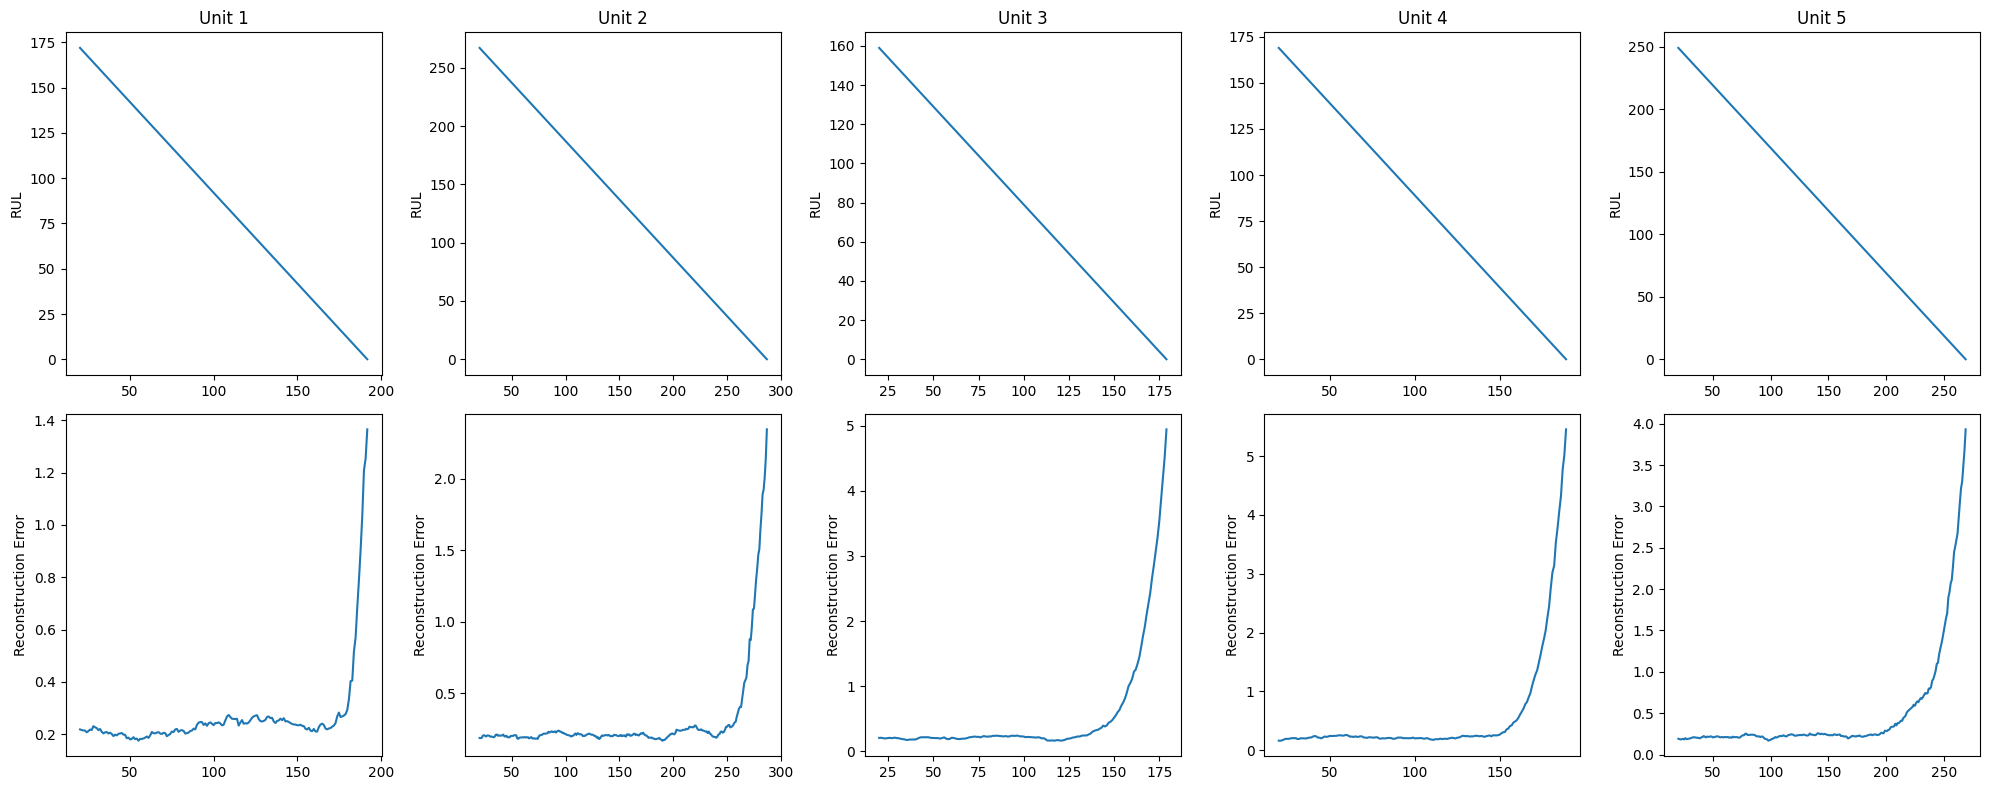

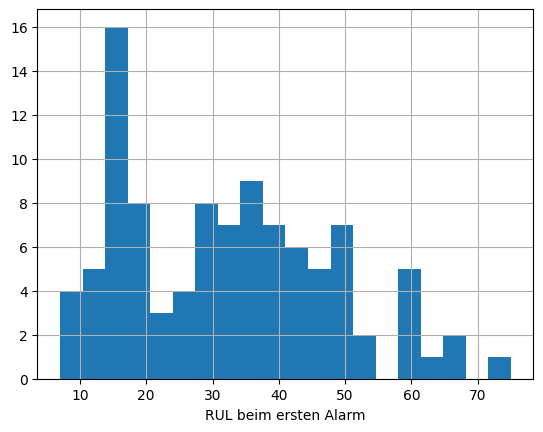

In [6]:
PLOTS_DIR = Path(__file__).resolve().parents[1] / "03_plots" if "__file__" in dir() else Path.cwd().parent / "03_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=False)
for i, unit_id in enumerate(range(1, 6)):
    unit = train_result[train_result["unit_id"] == unit_id].sort_values("cycles")
    axes[0, i].plot(unit["cycles"], unit["RUL"])
    axes[0, i].set_ylabel("RUL")
    axes[0, i].set_title(f"Unit {unit_id}")
    axes[1, i].plot(unit["cycles"], unit["reconstruction_error"])
    axes[1, i].set_ylabel("Reconstruction Error")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "lstm_rul_vs_reconstruction.png", dpi=150, bbox_inches="tight")
plt.show()

first_alarm.hist(bins=20)
plt.xlabel("RUL beim ersten Alarm")
plt.savefig(PLOTS_DIR / "lstm_first_anomaly_histogram.png", dpi=150, bbox_inches="tight")
plt.show()


## Testphase: 100 unbekannte Triebwerke

- Triebwerke **MIT Alarm** sollten niedrige RUL haben
- Triebwerke **OHNE Alarm** sollten hohe RUL haben

In [7]:
model.eval()
all_sequences, labels = create_sequences(test_df, window_size, useful_sensors)
all_tensor = torch.FloatTensor(all_sequences)

with torch.no_grad():
    reconstructed = model(all_tensor)
    errors = torch.mean((all_tensor - reconstructed) ** 2, dim=(1, 2))

test_result = pd.DataFrame(labels, columns=["unit_id", "cycle"])
test_result["reconstruction_error"] = errors.numpy()
test_result["anomaly_flag"] = test_result["reconstruction_error"] > threshold
test_result = test_result.merge(rul_df, on="unit_id", how="left")
alarm_analysis(test_result, rul_df)

Units mit Alarm: 24 / 100

RUL-Verteilung (MIT Alarm):
count    24.0
mean     21.5
std      13.9
min       7.0
25%      10.0
50%      19.5
75%      28.0
max      54.0
Name: RUL, dtype: float64

RUL-Verteilung (OHNE Alarm):
count     76.0
mean      92.6
std       31.9
min       18.0
25%       75.8
50%       96.5
75%      115.0
max      145.0
Name: RUL, dtype: float64
